In [1]:
from made.data_pipeline.data.datacomp_handler import decode_webdataset, get_next_batch
from made.data_pipeline.utils import collect_tar_files

In [2]:
dataset = iter(decode_webdataset(
    collect_tar_files("/home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output"), # 20220 samples read in 1m 10s
    get_images=True,
    get_captions=True,
    batch_size=2000
))

2025-06-16 17:51:45,087	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output


In [4]:

from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
processor = AutoProcessor.from_pretrained("leobaro/DFN-public")
model = AutoModelForZeroShotImageClassification.from_pretrained("leobaro/DFN-public").eval().to("cuda")

In [5]:
uid_score = {}
i_dataset = iter(dataset)
while True:
    batch = get_next_batch(i_dataset)
    if batch is None:
        break
    uids, images, captions = batch
    print("New batch!")
    for uid, img, txt in zip(uids, images, captions):
        try:
            inputs = processor(text=[txt], images=[img], return_tensors="pt", padding=True, truncation=True, max_length=77).to("cuda")
        except Exception as e:
            print(e)
            continue
        outputs = model(**inputs)
        uid_score[uid] = outputs.logits_per_image.item()


New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!


In [10]:
import pandas as pd
pd.DataFrame(uid_score.values()).describe()

,0
count,46111.000000
mean,2.959877
std,1.477490
min,-2.386162
25%,1.893348
50%,3.084493
75%,4.111238
max,7.066980


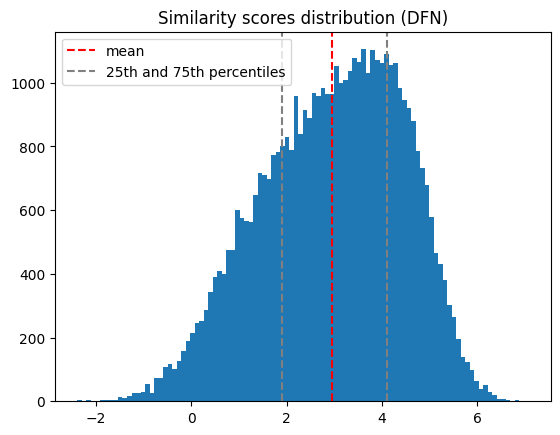

In [6]:
import matplotlib.pyplot as plt
import numpy as np
plt.title("Similarity scores distribution (DFN)")
sim_scores = list(uid_score.values())
plt.hist(sim_scores, bins=100)
plt.axvline(x=np.mean(sim_scores), color='red', linestyle='--', label='mean')
plt.axvline(x=np.percentile(sim_scores, 25), color='grey', linestyle='--', label='25th and 75th percentiles')
plt.axvline(x=np.percentile(sim_scores, 75), color='grey', linestyle='--')
plt.legend()
plt.show()


In [12]:
p_75 = np.percentile(sim_scores, 75)
p_25 = np.percentile(sim_scores, 25)
print(p_75, p_25)

4.111238479614258 1.8933475017547607


In [37]:
percentile_ranges = [(x,x+10) for x in range(30, 90, 10)]
percentile_ranges

[(10, 20),
 (20, 30),
 (30, 40),
 (40, 50),
 (50, 60),
 (60, 70),
 (70, 80),
 (80, 90),
 (90, 100)]

In [ ]:
import random
data_to_plot = {}
max_samples_per_columns = 4
for row_i, percentile_range in enumerate(percentile_ranges):
    p_min, p_max = np.percentile(sim_scores, percentile_range[0]), np.percentile(sim_scores, percentile_range[1])
    uids = [uid for uid, score in uid_score.items() if score > p_min and score < p_max]
    scores = [score for uid, score in uid_score.items() if score > p_min and score < p_max]
    random_index = random.sample(range(0, len(uids)), max_samples_per_columns)
    random_uids = [uids[i] for i in random_index]
    random_scores = [scores[i] for i in random_index]
    uids, images, captions = find_samples_with_uids(random_uids, max_samples_per_columns)
    data_to_plot[f"{percentile_range}"] = uids, images, captions, random_scores 


2025-06-16 18:40:07,780	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output
2025-06-16 18:40:13,129	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output
2025-06-16 18:40:18,932	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output
2025-06-16 18:40:24,541	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output
2025-06-16 18:40:30,730	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output
2025-06-16 18:40:36,443	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output
2025-06-16 18:40:42,095	INFO utils.py:41 -- Found 20

In [50]:
data_to_plot["(30, 40)"]

(['26edd202cba0c1e89a475a1d8d09efe1',
  '7e7f0fa9d7ec2588d43dcc68094db370',
  '05091797d14e2d74b2bc4cda2ad07a2c',
  '7e7f0fa9d7ec2588d43dcc68094db370'],
 [<PIL.Image.Image image mode=RGB size=450x313>,
  <PIL.Image.Image image mode=RGB size=115x115>,
  <PIL.Image.Image image mode=RGB size=300x219>,
  <PIL.Image.Image image mode=RGB size=115x115>],
 ['a happy woman outdoors relaxing',
  'FootJoy Freestyle Previous Season Style',
  'Aleksey Venetsianov, In the ploughed field. Spring. Cats at work',
  'FootJoy Freestyle Previous Season Style'],
 [2.4957656860351562,
  2.1941142082214355,
  2.5990986824035645,
  2.209495782852173])

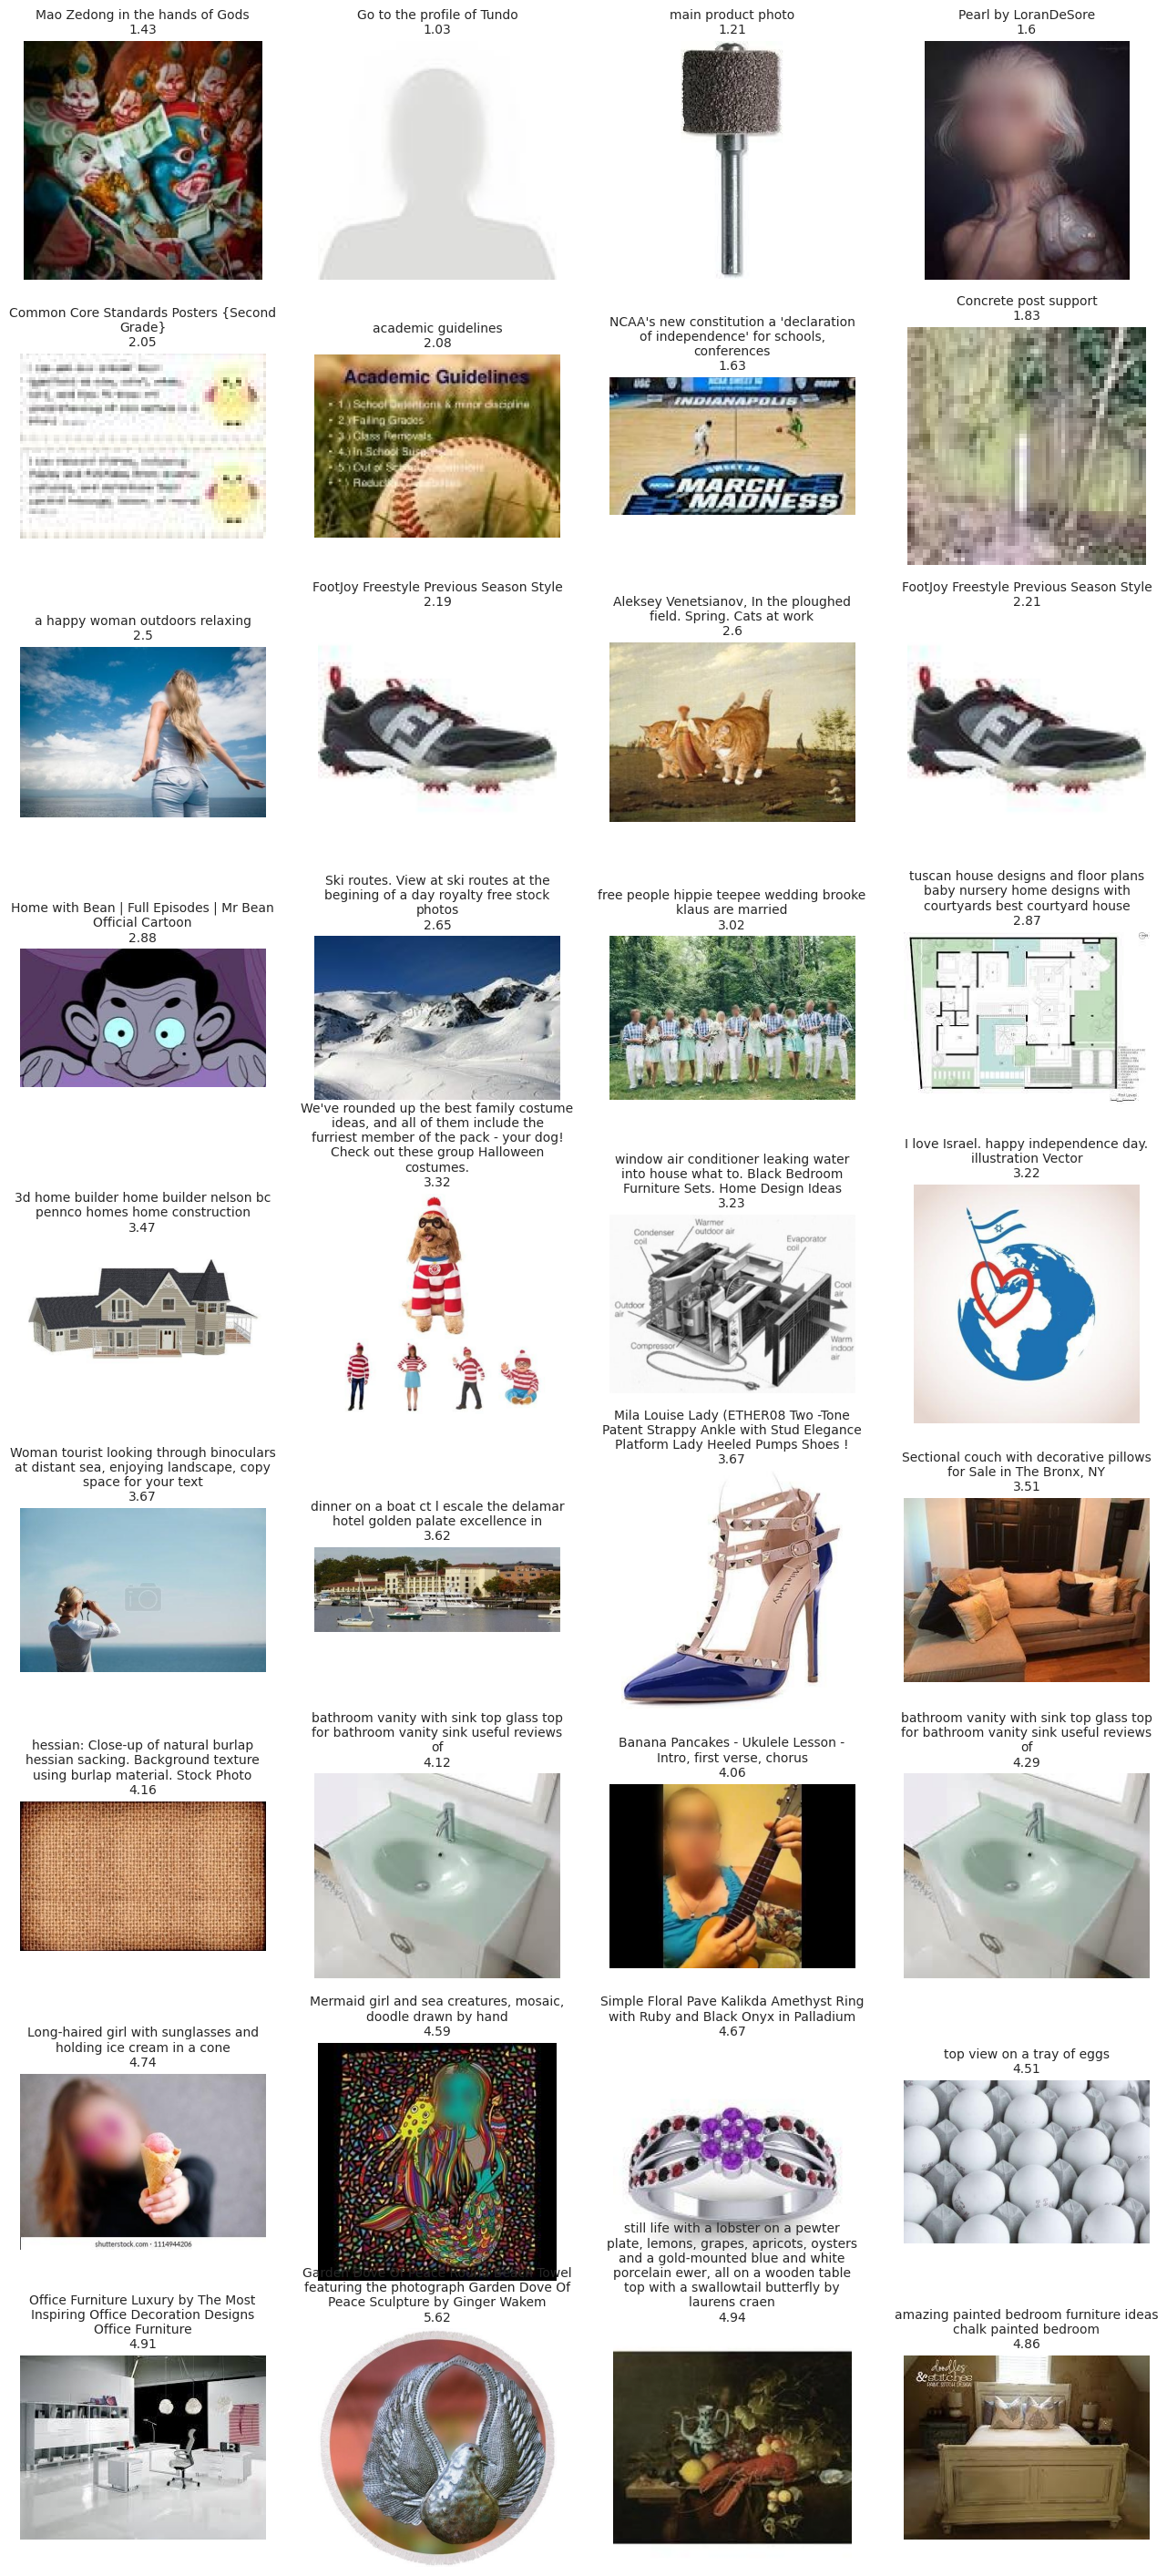

In [61]:
import seaborn as sns
import textwrap

sns.set_theme(style="darkgrid")
num_cols = 4
num_rows = len(percentile_ranges)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 4 * num_rows))
#fig.suptitle("DFN similarity scores percentiles", fontsize=16)

row = 0
for percentile_range in data_to_plot.keys():
    uids, images, captions, scores = data_to_plot[percentile_range]
    row_axes = axes[row]

    col = 0
    for uid, image, caption, score in zip(uids, images, captions, scores):
        col_ax = row_axes[col] 
        col_ax.imshow(image)
        wrapped_caption = "\n".join(textwrap.wrap(caption, width=40))
        col_ax.set_title(f"{wrapped_caption}\n{round(score, 2)}", fontsize=10)
        col_ax.axis("off")
        col += 1
    row += 1

In [31]:
uids_gt_75_perc = [uid for uid, score in uid_score.items() if score > p_75]
uids_lt_25_perc = [uid for uid, score in uid_score.items() if score < p_25]
uids_between_25_and_75_perc = [uid for uid, score in uid_score.items() if score > p_25 and score < p_75]

scores_gt_75_perc = [score for uid, score in uid_score.items() if score > p_75]
scores_lt_25_perc = [score for uid, score in uid_score.items() if score < p_25]
scores_between_25_and_75_perc = [score for uid, score in uid_score.items() if score > p_25 and score < p_75]

In [32]:
import random

# random sample 10 uids without replacement from each list
index_gt_75_perc = random.sample(range(0, len(uids_gt_75_perc)), 10)
index_gt_25_perc = random.sample(range(0, len(uids_lt_25_perc)), 10)
index_between_25_and_75_perc = random.sample(range(0, len(uids_between_25_and_75_perc)), 10)

uids_gt_75_perc = [uids_gt_75_perc[i] for i in index_gt_75_perc]
uids_lt_25_perc = [uids_lt_25_perc[i] for i in index_gt_25_perc]
uids_between_25_and_75_perc = [uids_between_25_and_75_perc[i] for i in index_between_25_and_75_perc]

In [40]:
def find_samples_with_uids(uid_list, n):
    dataset = iter(decode_webdataset(
        collect_tar_files("/home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output"), # 20220 samples read in 1m 10s
        get_images=True,
        get_captions=True,
        batch_size=n,
        valid_uids=uid_list
    ))
    uids, images, captions = get_next_batch(iter(dataset))
    return uids, images, captions




## Greater than 75 percentile

In [ ]:
display_uids(uids_gt_75_perc, scores_gt_75_perc)

## Lower than 25 percentile

2025-06-16 18:12:30,608	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output


8a0811eea83da19185493294d90d5c77
The modular system makes the vessel fit for purpose for a variety of professional uses


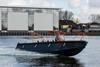

faf649b896db659a1336b956a346a035
Don't mess with the wrong guy


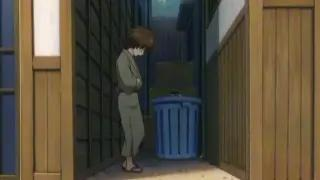

bfe2ea7d42b6cdaee904c14df7de8e9d
Stop Me Before I Invent Plaid! Canvas Print


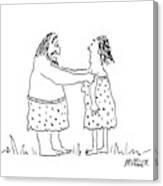

8a933acdd61e671824fbc9b69c985477
Additional Product Image


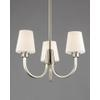

8a0811eea83da19185493294d90d5c77
The modular system makes the vessel fit for purpose for a variety of professional uses


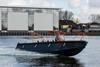

c891108c52b158241a10dcb31adeffea
Brilliant green at the base of the Seven Sisters Cliffs, Seaford, England


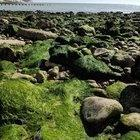

8842487ca02835851f7e0c12501efb02
untitled image


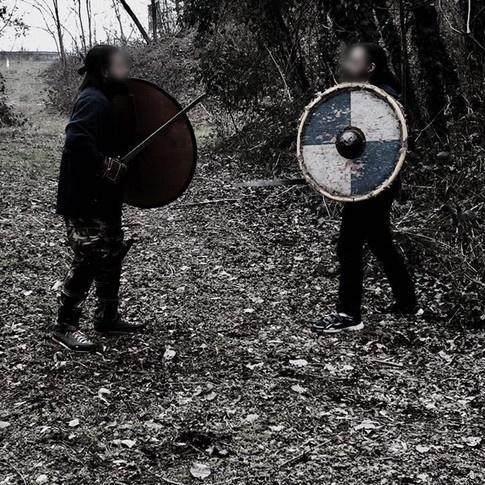

9f1e844521e3bc325fa4b938a4ec1096
Wire gage calculator ac image collections wiring table and diagram wire gage calculator ac thank you for visiting keyboard keysfo nowadays were excited to declare that we have discovered an incredibly interesting topic to greentooth Images


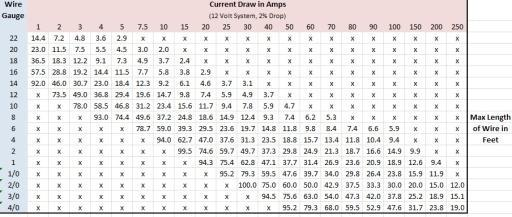

1887911ef8ef38824989992d014e882b
How to Calculate Preferred Stock


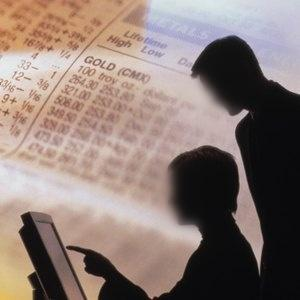

f91c056eb3d7ac2e215ac97953da1cad
File photo of Mohamed Abushahab, the UAE Mission to the UN's deputy permanent representative. (Twitter)


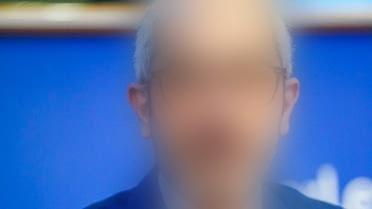

2df3b9aa68826b0a23dfe9921e070423
Listing main image


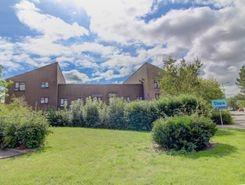

In [18]:
display_uids(uids_lt_25_perc)

## Between 25 and 75 percentile

2025-06-16 18:12:53,391	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output


61c96e7462ab90b27186896c7e4a8995
Water Cooled R180n Single Cylinder Diesel Engine for Sale


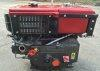

954b6754fbe0157289a263f92efc2aee
Activity Digital Art - Polygraph Needle And Drawing by Allan Swart


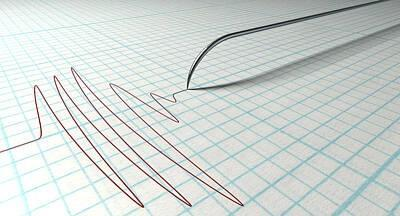

f3f40c4e8b5ca34be7e84d3e434e097d
Wireless charger with Nest Hub mode


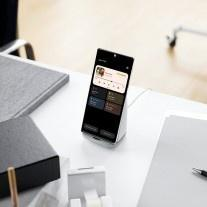

fcd07f4cd363776caf6af21fcdb7fd6a
Image of a businessman in dark suit playing chess - stock photo


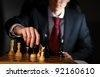

1a6f1533e9f5da354f09a8d4587e9c33
shipping container apartment complex - Google Search Capsule Hotel, Project Site, Unusual Buildings, Student House, Apartment Complexes, Quality Kitchens, Japanese Artists, Rental Apartments, Architecture


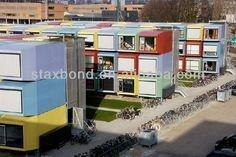

c20f461a1cd9548b2d32e92d13319738
A gorgeous Rwandan sunset over the water.


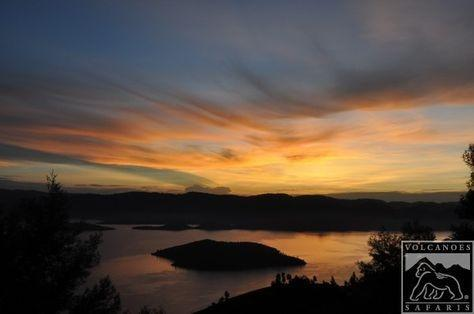

c4816a02149faec1d0581e34c23c7d23
LED Hugh Bay (H Series) LED High Bay (H Series) INDUSTRIAL LUMINAIRES


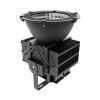

8948f999d95edbe7b0ec6fbe71ff324f
Fed Flags Worry on Global Tumult, Doesn&#8217;t Rule Out March Rate Hike


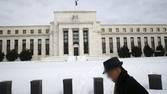

fcd07f4cd363776caf6af21fcdb7fd6a
Image of a businessman in dark suit playing chess - stock photo


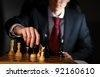

7b935087b5b40492bb2e238d5f554a6b
Green tea with sieve Royalty Free Stock Image


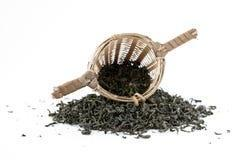

b809bcda8b5bc98d30fc5255b5d51ca8
interior kitchen ideas kitchen interior design ideas decobizz


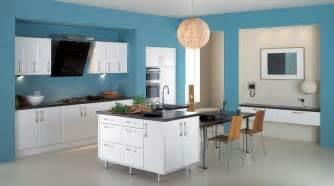

1a6f1533e9f5da354f09a8d4587e9c33
shipping container apartment complex - Google Search Capsule Hotel, Project Site, Unusual Buildings, Student House, Apartment Complexes, Quality Kitchens, Japanese Artists, Rental Apartments, Architecture


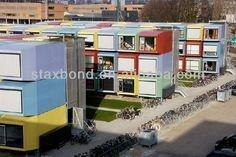

61c96e7462ab90b27186896c7e4a8995
Water Cooled R180n Single Cylinder Diesel Engine for Sale


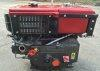

In [19]:
display_uids(uids_between_25_and_75_perc)